## 3η Εργασία: Βαθιά Μάθηση

### Ομάδα 34

#### Ζακυνθινός Αντώνης - 03117441
#### Παπαϊωάννου Γεώργιος - 03117836
#### Στάβαρης Δημοσθένης - 03117404

### Out of the box

#### Ακολουθώντας τα βήματα του tutorial υλοποιήσαμε αρχικά το out of the box μοντέλο όπως φαίνεται παρακάτω, περιγράφουμε συνοπτικά τα βήματα.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import collections
import random
import numpy as np
import os
import time
import json
import nltk
from PIL import Image
from nltk.util import ngrams
from nltk.translate import bleu_score
from nltk.translate.bleu_score import SmoothingFunction
from keras.applications.xception import Xception
from keras.layers import Input, Dense#Keras to build our CNN and LSTM
from keras.layers import LSTM, Embedding, Dropout

#### Αρχικά γίνονται τα απαραίτητα import βιβλιοθηκών και κατεβάζουμε το τροποποιημένο flickr30k dataset που δίνεται στην εκφώνηση.

### Download and prepare the dataset

In [2]:
# Download image files
image_zip = tf.keras.utils.get_file('flickr30k-images-ecemod.zip',
                                      cache_subdir=os.path.abspath('.'),
                                      origin='https://spartacus.1337.cx/flickr-mod/flickr30k-images-ecemod.zip',
                                      extract=True)

images_path = os.path.dirname(image_zip)
os.remove(image_zip)

4376395776/4376381805 [==============================] - 282s 0us/step


In [3]:
# Download train captions file
train_captions_file = tf.keras.utils.get_file('train_captions.csv',
                                           cache_subdir=os.path.abspath('.'),
                                           origin='https://spartacus.1337.cx/flickr-mod/train_captions.csv',
                                           extract=False)

# Download test files list
test_images_file = tf.keras.utils.get_file('test_images.csv',
                                           cache_subdir=os.path.abspath('.'),
                                           origin='https://spartacus.1337.cx/flickr-mod/test_images.csv',
                                           extract=False)

40960/29242 [==========================================] - 0s 0us/step


### Limit the size of the training set

#### Στη συνέχεια και αφού διαβάσουμε το αρχείο csv που κατεβάσαμε, κρατάμε μόνο 6000 εικόνες και αντίστοιχα 30000 captions που αντιστοιχούν σε αυτές καθώς έχουμε περίπου 5 caption ανα εικόνα. Αυτό γίνεται για πιο γρήγορη ετκέλεση λόγω των περιορισμένων πόρων που έχουμε.

In [4]:
annotations = pd.read_csv('train_captions.csv', sep='|', header=None)
annotations = annotations.transpose()
for row in range(annotations.shape[1]):
    annotations[row][2] = annotations[row][2][1:]

In [5]:
annotations

,0,1,2,3,4,5,6,7,8,9,...,148905,148906,148907,148908,148909,148910,148911,148912,148913,148914
0,_1000070808.jpg,_1000070808.jpg,_1000070808.jpg,_1000070808.jpg,_1000070808.jpg,_100007487.jpg,_100007487.jpg,_100007487.jpg,_100007487.jpg,_100007487.jpg,...,_99988530.jpg,_99988530.jpg,_99988530.jpg,_99988530.jpg,_99988530.jpg,_99999606.jpg,_99999606.jpg,_99999606.jpg,_99999606.jpg,_99999606.jpg
1,0,1,2,3,4,0,1,2,3,4,...,0,1,2,3,4,0,1,2,3,4
2,A little girl holds orange lilies while others...,A little girl at a wedding holds a bouquet of ...,Young girl in orange dress holding orange flow...,a girl at a wedding holding some orange flowers,A girl holds a bouquet of flowers,A young child walks down a gravel path lined w...,A racetrack with red chairs stacked beside fen...,A child in a striped shirt walks by some red c...,A child walking and leaving a trail behind them .,A little kid is walking next to red banners .,...,A city worker with the bright yellow vest is l...,A woman wearing a bright yellow jacket and hat...,A woman with a yellow jacket and matching hat ...,Person in neon green jacket and hat standing o...,A security person in lime green monitors the b...,A man in a gray shirt sits with several pairs ...,A man is sitting down and he is surrounded by ...,Older man with shoes in front and behind him .,This man has worked here for many decades .,an old shoemaker in his factory .


In [6]:
# Group all captions together having the same image ID.
image_path_to_caption = collections.defaultdict(list)
for row in range(annotations.shape[1]):
    caption =  f"<start> {annotations[row][2]}  <end>"
    image_path = "image_dir/" + annotations[row][0]
    image_path_to_caption[image_path].append(caption)

In [7]:
list(image_path_to_caption.items())[0]

('image_dir/_1000070808.jpg',
 ['<start> A little girl holds orange lilies while others celebrate an occasion in a garden setting .  <end>',
  '<start> A little girl at a wedding holds a bouquet of orange flowers .  <end>',
  '<start> Young girl in orange dress holding orange flowers .  <end>',
  '<start> a girl at a wedding holding some orange flowers  <end>',
  '<start> A girl holds a bouquet of flowers  <end>'])

In [8]:
image_paths = list(image_path_to_caption.keys())
random.shuffle(image_paths)

# Select the first 6000 image_paths from the shuffled set.
# Approximately each image id has 5 captions associated with it, so that will
# lead to 30,000 examples.
train_image_paths = image_paths[:6000]
print(len(train_image_paths))

6000


In [9]:
train_captions = []
img_name_vector = []

for image_path in train_image_paths:
    caption_list = image_path_to_caption[image_path]
    train_captions.extend(caption_list)
    img_name_vector.extend([image_path] * len(caption_list))

<start> A baseball player in a red jersey throwing a ball at the pitchers mound .  <end>


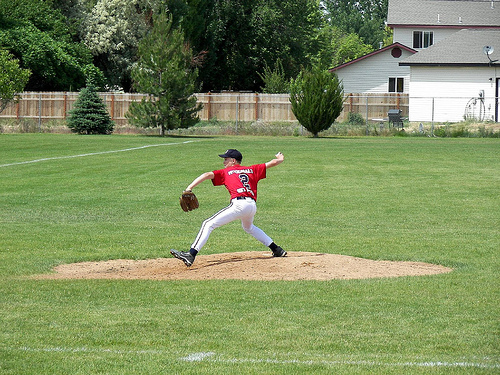

In [10]:
print(train_captions[0])
Image.open(img_name_vector[0])

### Preprocess the images using InceptionV3

#### Ύστερα προεπεξεργαζόμαστε τις εικόνες για να βρεθούν στην κατάλληλη μορφή που τις περιμένει ο encoder InceptionV3. Τις κάνουμε resize σε μέγεθος 299x299 pixel και στη συνέχεια τις προεξεργαζόμαστε με τη μέθοδο preprocess_input ώστε να έχουν τα pixel εύρος από -1 έως 1.

In [11]:
def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.keras.layers.Resizing(299, 299)(img)
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img, image_path

### Initialize InceptionV3 and load the pretrained Imagenet weights

#### Στη συνέχεια δημιουργούμε ένα μοντέλο tf.keras με output layer το τελευταίο convolutional layer τις αρχιτεκτονικής InceptionV3. Περνάμε όλες τις εικόνες από το δίκτυο και αποθηκεύουμε το αποτέλεσμα σε ένα λεξικό.

In [12]:
image_model = tf.keras.applications.InceptionV3(include_top=False, weights='imagenet')
new_input = image_model.input
hidden_layer = image_model.layers[-1].output

image_features_extract_model = tf.keras.Model(new_input, hidden_layer)

2022-03-09 18:47:44.630210: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-03-09 18:47:44.758100: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-03-09 18:47:44.758927: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-03-09 18:47:44.760071: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

87924736/87910968 [==============================] - 0s 0us/step


node zero
2022-03-09 18:47:44.761062: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-03-09 18:47:44.761686: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-03-09 18:47:46.644548: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-03-09 18:47:46.645359: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-03-09 18:47:46.646052: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node r

### Caching the features extracted from InceptionV3

#### Κάνουμε την προεπεξεργασία για κάθε εικόνα και αποθηκεύουμε την έξοδο του δικτύου.

In [13]:
!pip install tqdm

In [14]:
from tqdm import tqdm

# Get unique images
encode_train = sorted(set(img_name_vector))

# Feel free to change batch_size according to your system configuration
image_dataset = tf.data.Dataset.from_tensor_slices(encode_train)
image_dataset = image_dataset.map(
  load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(16)

for img, path in tqdm(image_dataset):
    batch_features = image_features_extract_model(img)
    batch_features = tf.reshape(batch_features,
                              (batch_features.shape[0], -1, batch_features.shape[3]))

    for bf, p in zip(batch_features, path):
        path_of_feature = p.numpy().decode("utf-8")
        np.save(path_of_feature, bf.numpy())

  0%|          | 0/375 [00:00<?, ?it/s]2022-03-09 18:48:04.541237: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)
2022-03-09 18:48:05.511516: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005
100%|██████████| 375/375 [01:06<00:00,  5.64it/s]


### Preprocess and tokenize the captions

#### Έπειτα μετατρέπουμε τις περιγραφές σε σειρές ακεραίων αριθμών με το Text Vectorization.

In [15]:
caption_dataset = tf.data.Dataset.from_tensor_slices(train_captions)

# We will override the default standardization of TextVectorization to preserve
# "<>" characters, so we preserve the tokens for the <start> and <end>.
def standardize(inputs):
    inputs = tf.strings.lower(inputs)
    return tf.strings.regex_replace(inputs, r"!\"#$%&\(\)\*\+.,-/:;=?@\[\\\]^_`{|}~", "")

# Max word count for a caption.
max_length = 50
# Use the top 5000 words for a vocabulary.
vocabulary_size = 5000
tokenizer = tf.keras.layers.TextVectorization(
    max_tokens=vocabulary_size,
    standardize=standardize,
    output_sequence_length=max_length)
# Learn the vocabulary from the caption data.
tokenizer.adapt(caption_dataset)

In [16]:
# Create the tokenized vectors
cap_vector = caption_dataset.map(lambda x: tokenizer(x))

In [17]:
# Create mappings for words to indices and indicies to words.
word_to_index = tf.keras.layers.StringLookup(
    mask_token="",
    vocabulary=tokenizer.get_vocabulary())
index_to_word = tf.keras.layers.StringLookup(
    mask_token="",
    vocabulary=tokenizer.get_vocabulary(),
    invert=True)

### Split the data into training and testing

In [18]:
img_to_cap_vector = collections.defaultdict(list)
for img, cap in zip(img_name_vector, cap_vector):
    img_to_cap_vector[img].append(cap)

# Create training and validation sets using an 80-20 split randomly.
img_keys = list(img_to_cap_vector.keys())
random.shuffle(img_keys)

slice_index = int(len(img_keys)*0.8)
img_name_train_keys, img_name_val_keys = img_keys[:slice_index], img_keys[slice_index:]

img_name_train = []
cap_train = []
for imgt in img_name_train_keys:
    capt_len = len(img_to_cap_vector[imgt])
    img_name_train.extend([imgt] * capt_len)
    cap_train.extend(img_to_cap_vector[imgt])

img_name_val = []
cap_val = []
for imgv in img_name_val_keys:
    capv_len = len(img_to_cap_vector[imgv])
    img_name_val.extend([imgv] * capv_len)
    cap_val.extend(img_to_cap_vector[imgv])

In [19]:
len(img_name_train), len(cap_train), len(img_name_val), len(cap_val)

(24000, 24000, 6000, 6000)

### Create a tf.data dataset for training

In [20]:
# Feel free to change these parameters according to your system's configuration

BATCH_SIZE = 64
BUFFER_SIZE = 1000
embedding_dim = 256
units = 512
num_steps = len(img_name_train) // BATCH_SIZE
# Shape of the vector extracted from InceptionV3 is (64, 2048)
# These two variables represent that vector shape
features_shape = 2048
attention_features_shape = 64

In [21]:
# Load the numpy files
def map_func(img_name, cap):
    img_tensor = np.load(img_name.decode('utf-8')+'.npy')
    return img_tensor, cap

In [22]:
dataset = tf.data.Dataset.from_tensor_slices((img_name_train, cap_train))

# Use map to load the numpy files in parallel
dataset = dataset.map(lambda item1, item2: tf.numpy_function(
          map_func, [item1, item2], [tf.float32, tf.int64]),
          num_parallel_calls=tf.data.AUTOTUNE)

# Shuffle and batch
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

### Model

#### Παρακάτω είναι το μοντέλο το οποίο όπως προαναφέραμε εξάγει τα χαρακτηριστικά του τελευταίου συνελικτικού επιπέδου από το InceptionV3. Τελικά το διάνυσμα περνάει από τον CNN Encoder και το RNN, που στο out of the box είναι GRU με 512 units, προβλέπει την επόμενη λέξη.

In [23]:
class BahdanauAttention(tf.keras.Model):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, features, hidden):
        # features(CNN_encoder output) shape == (batch_size, 64, embedding_dim)

        # hidden shape == (batch_size, hidden_size)
        # hidden_with_time_axis shape == (batch_size, 1, hidden_size)
        hidden_with_time_axis = tf.expand_dims(hidden, 1)

        # attention_hidden_layer shape == (batch_size, 64, units)
        attention_hidden_layer = (tf.nn.tanh(self.W1(features) +
                                             self.W2(hidden_with_time_axis)))

        # score shape == (batch_size, 64, 1)
        # This gives you an unnormalized score for each image feature.
        score = self.V(attention_hidden_layer)

        # attention_weights shape == (batch_size, 64, 1)
        attention_weights = tf.nn.softmax(score, axis=1)

        # context_vector shape after sum == (batch_size, hidden_size)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

In [24]:
class CNN_Encoder(tf.keras.Model):
    # Since you have already extracted the features and dumped it
    # This encoder passes those features through a Fully connected layer
    def __init__(self, embedding_dim):
        super(CNN_Encoder, self).__init__()
        # shape after fc == (batch_size, 64, embedding_dim)
        self.fc = tf.keras.layers.Dense(embedding_dim)

    def call(self, x):
        x = self.fc(x)
        x = tf.nn.relu(x)
        return x

In [25]:
class RNN_Decoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size):
        super(RNN_Decoder, self).__init__()
        self.units = units

        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(self.units,
                                       return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer='glorot_uniform')
        self.fc1 = tf.keras.layers.Dense(self.units)
        self.fc2 = tf.keras.layers.Dense(vocab_size)

        self.attention = BahdanauAttention(self.units)

    def call(self, x, features, hidden):
        # defining attention as a separate model
        context_vector, attention_weights = self.attention(features, hidden)

        # x shape after passing through embedding == (batch_size, 1, embedding_dim)
        x = self.embedding(x)

        # x shape after concatenation == (batch_size, 1, embedding_dim + hidden_size)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        
        # passing the concatenated vector to the GRU
        output, state = self.gru(x)

        # shape == (batch_size, max_length, hidden_size)
        x = self.fc1(output)

        # x shape == (batch_size * max_length, hidden_size)
        x = tf.reshape(x, (-1, x.shape[2]))

        # output shape == (batch_size * max_length, vocab)
        x = self.fc2(x)

        return x, state, attention_weights

    def reset_state(self, batch_size):
        return tf.zeros((batch_size, self.units))

In [26]:
encoder = CNN_Encoder(embedding_dim)
decoder = RNN_Decoder(embedding_dim, units, tokenizer.vocabulary_size())

In [27]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')


def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)

    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    return tf.reduce_mean(loss_)

### Checkpoint

In [28]:
checkpoint_path = "./checkpoints/train"
ckpt = tf.train.Checkpoint(encoder=encoder, decoder=decoder, optimizer=optimizer)
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

In [29]:
start_epoch = 0
if ckpt_manager.latest_checkpoint:
    start_epoch = int(ckpt_manager.latest_checkpoint.split('-')[-1])
    # restoring the latest checkpoint in checkpoint_path
    ckpt.restore(ckpt_manager.latest_checkpoint)

### Training

#### Παρακάτω είναι η εκπαίδευση του μοντέλου κατά την οποία αρχικά εξάγουμε τα features και τα περνάμε από τον encoder, περνάμε την έξοδο του encoder, το hidden state και την είσοδο του decoder στον decoder και τελικά αυτός μας επιστρέφει τις προβλέψεις και το hidden state του. Το hidden state αυτό (του decoder) περνιέται από το μοντέλο και με τη βοήθεια του υπολογίζουμε το loss. Έπειτα χρησιμοποιείται η τεχνική teacher forcing που είναι μια τεχνική που η λέξη στόχος περνιέται σαν επόμενη είσοδος στον decoder και τελικά υπολογίζουμε τα gradients και τα εφαρμόζουμε στον optimizer και κάνουμε backpropagate.

In [30]:
# adding this in a separate cell because if you run the training cell
# many times, the loss_plot array will be reset
loss_plot = []

In [31]:
@tf.function
def train_step(img_tensor, target):
    loss = 0

    # initializing the hidden state for each batch
    # because the captions are not related from image to image
    hidden = decoder.reset_state(batch_size=target.shape[0])

    dec_input = tf.expand_dims([word_to_index(tf.convert_to_tensor(''))]* target.shape[0], 1)

    with tf.GradientTape() as tape:
        features = encoder(img_tensor)

        for i in range(1, target.shape[1]):
            # passing the features through the decoder
            predictions, hidden, _ = decoder(dec_input, features, hidden)

            loss += loss_function(target[:, i], predictions)

            # using teacher forcing
            dec_input = tf.expand_dims(target[:, i], 1)

    total_loss = (loss / int(target.shape[1]))

    trainable_variables = encoder.trainable_variables + decoder.trainable_variables

    gradients = tape.gradient(loss, trainable_variables)

    optimizer.apply_gradients(zip(gradients, trainable_variables))

    return loss, total_loss

In [32]:
EPOCHS = 20
start_epoch = 0

for epoch in range(start_epoch, EPOCHS):
    start = time.time()
    total_loss = 0

    for (batch, (img_tensor, target)) in enumerate(dataset):
        batch_loss, t_loss = train_step(img_tensor, target)
        total_loss += t_loss

        if batch % 100 == 0:
            average_batch_loss = batch_loss.numpy()/int(target.shape[1])
            print(f'Epoch {epoch+1} Batch {batch} Loss {average_batch_loss:.4f}')
    # storing the epoch end loss value to plot later
    loss_plot.append(total_loss / num_steps)

    if epoch % 5 == 0:
        ckpt_manager.save()

    print(f'Epoch {epoch+1} Loss {total_loss/num_steps:.6f}')
    print(f'Time taken for 1 epoch {time.time()-start:.2f} sec\n')

2022-03-09 18:50:48.583497: W tensorflow/core/framework/cpu_allocator_impl.cc:80] Allocation of 33554432 exceeds 10% of free system memory.
2022-03-09 18:50:48.904106: W tensorflow/core/framework/cpu_allocator_impl.cc:80] Allocation of 33554432 exceeds 10% of free system memory.


Epoch 1 Batch 0 Loss 2.4396


2022-03-09 18:51:42.694532: W tensorflow/core/framework/cpu_allocator_impl.cc:80] Allocation of 33554432 exceeds 10% of free system memory.
2022-03-09 18:51:42.895014: W tensorflow/core/framework/cpu_allocator_impl.cc:80] Allocation of 33554432 exceeds 10% of free system memory.
2022-03-09 18:51:43.104858: W tensorflow/core/framework/cpu_allocator_impl.cc:80] Allocation of 33554432 exceeds 10% of free system memory.


Epoch 1 Batch 100 Loss 1.3184
Epoch 1 Batch 200 Loss 1.1665
Epoch 1 Batch 300 Loss 1.2662
Epoch 1 Loss 1.270981
Time taken for 1 epoch 116.00 sec

Epoch 2 Batch 0 Loss 1.0469
Epoch 2 Batch 100 Loss 1.0321
Epoch 2 Batch 200 Loss 1.0688
Epoch 2 Batch 300 Loss 0.9638
Epoch 2 Loss 1.011083
Time taken for 1 epoch 61.73 sec

Epoch 3 Batch 0 Loss 0.9636
Epoch 3 Batch 100 Loss 0.8725
Epoch 3 Batch 200 Loss 0.8897
Epoch 3 Batch 300 Loss 0.9500
Epoch 3 Loss 0.920107
Time taken for 1 epoch 61.94 sec

Epoch 4 Batch 0 Loss 0.8038
Epoch 4 Batch 100 Loss 0.9398
Epoch 4 Batch 200 Loss 0.9261
Epoch 4 Batch 300 Loss 0.9520
Epoch 4 Loss 0.858756
Time taken for 1 epoch 62.01 sec

Epoch 5 Batch 0 Loss 0.8136
Epoch 5 Batch 100 Loss 0.7786
Epoch 5 Batch 200 Loss 0.7621
Epoch 5 Batch 300 Loss 0.7569
Epoch 5 Loss 0.807799
Time taken for 1 epoch 61.55 sec

Epoch 6 Batch 0 Loss 0.7948
Epoch 6 Batch 100 Loss 0.7707
Epoch 6 Batch 200 Loss 0.7506
Epoch 6 Batch 300 Loss 0.8240
Epoch 6 Loss 0.763988
Time taken for 1 

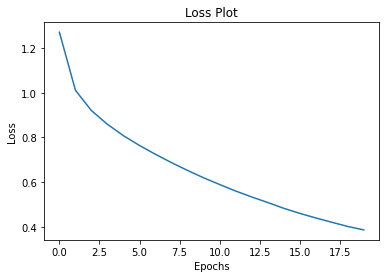

In [33]:
plt.plot(loss_plot)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.show()

### Caption!

#### Εδώ χρησιμοποιούμε τη συνάρτηση evaluate που μοιάζει με το training, όμως δεν χρησιμοποιείται teacher forcing αλλά η είσοδος του decoder είναι οι προηγούμενες προβλέψεις μαζί με το hidden state και την έξοδο του encoder. Η πρόβλεψη σταματά μόλις το μοντέλο προβλέψει το end token. Επίσης αποθηκεύονται τα attention weights σε κάθε βήμα.

In [34]:
def evaluate(image):
    attention_plot = np.zeros((max_length, attention_features_shape))

    hidden = decoder.reset_state(batch_size=1)

    temp_input = tf.expand_dims(load_image(image)[0], 0)
    img_tensor_val = image_features_extract_model(temp_input)
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))

    features = encoder(img_tensor_val)

    dec_input = tf.expand_dims([word_to_index(tf.convert_to_tensor('<start>'))], 0)
    result = []

    for i in range(max_length):
        predictions, hidden, attention_weights = decoder(dec_input, features, hidden)

        attention_plot[i] = tf.reshape(attention_weights, (-1, )).numpy()

        predicted_id = tf.random.categorical(predictions, 1)[0][0].numpy()
        
        #predicted_word = tf.compat.as_text(index_to_word(predicted_id).numpy())
        predicted_word = index_to_word(int(predicted_id)).numpy().decode('UTF-8')
        result.append(predicted_word)

        if predicted_word == '<end>':
            return result, attention_plot

        dec_input = tf.expand_dims([predicted_id], 0)

    attention_plot = attention_plot[:len(result), :]
    return result, attention_plot

In [35]:
def plot_attention(image, result, attention_plot):
    temp_image = np.array(Image.open(image))
    
    fig = plt.figure(figsize=(20, 20))
    
    len_result = len(result)
    for i in range(len_result):
        temp_att = np.resize(attention_plot[i], (20, 20))
        grid_size = max(int(np.ceil(len_result/2)), 2)
        ax = fig.add_subplot(grid_size, grid_size, i+1)
        ax.set_title(result[i])
        img = ax.imshow(temp_image)
        ax.imshow(temp_att, cmap='gray', alpha=0.6, extent=img.get_extent())
    
    plt.tight_layout()
    plt.show()

Real Caption: <start> a lab dog is standing on a fallen tree trunk with a guy in the background . <end>
Prediction Caption: white dog has been photographs from a tree branch , a dog stuck down a tree branch in the field near a tree branch , a dog near a tree branch . <end>


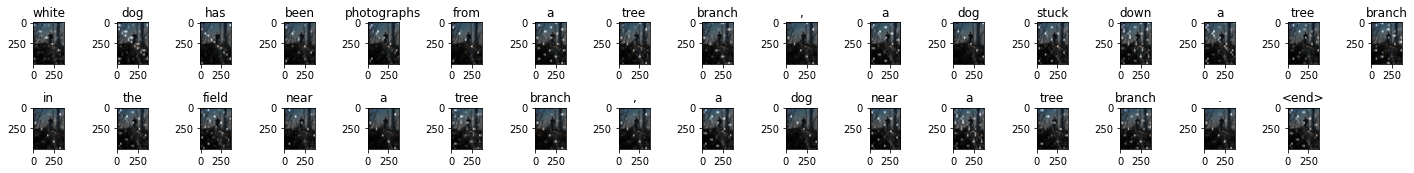

In [36]:
# captions on the validation set
rid = np.random.randint(0, len(img_name_val))
image = img_name_val[rid]
real_caption = ' '.join([tf.compat.as_text(index_to_word(i).numpy())
                         for i in cap_val[rid] if i not in [0]])
result, attention_plot = evaluate(image)

print('Real Caption:', real_caption)
print('Prediction Caption:', ' '.join(result))
plot_attention(image, result, attention_plot)

### Evaluate Models

#### Αφού δημιουργήσαμε captions ήρθε η ώρα να τα αξιολογήσουμε κάπως και αυτό θα γίνει με τη βοήθεια της συνάρτησης get_bleu. Η οποία είτε για 1 εικόνα είτε για πολλές παίρνει κάποια αληθινά captions (references) και κάποιο που παράγεται από το δίκτυο μας (hypothesis) και με τη βοήθεια του bleu score αξιολογεί με μια βαθμολογία από το 0 εως το 1. Το bleu score είναι ο σταθμισμένος μέσος όρος ανάμεσα στο πλήθος των κοινών unigrams, bigrams, trigrams και fourgrams ανάμεσα σε references και hypothesis.  

In [37]:
def get_bleu(list_id):
    references = []
    hypothesis = []
    verbal = len(list_id) == 1
    if verbal: print('References')
    for rid in list_id:
        image_ref = []
        for ref in range(5):
            reference = [tf.compat.as_text(index_to_word(i).numpy()) for i in cap_val[rid + ref] if i not in [0]][1:-1]
            if verbal: print(' '.join(reference))
            image_ref.append(reference)
        references.append(image_ref)
        image = img_name_val[rid]
        res, attention_plot = evaluate(image)
        res = res[:-1]
        hypothesis.append(res)
    bleu_score = nltk.translate.bleu_score.corpus_bleu(references, hypothesis, weights=(0.4, 0.3, 0.2, 0.1), smoothing_function=SmoothingFunction().method1)
    if verbal:
        print('Hypothesis')
        print(' '.join(res))
    print('Bleu Score = ', bleu_score)
    if verbal: plot_attention(image, res, attention_plot)

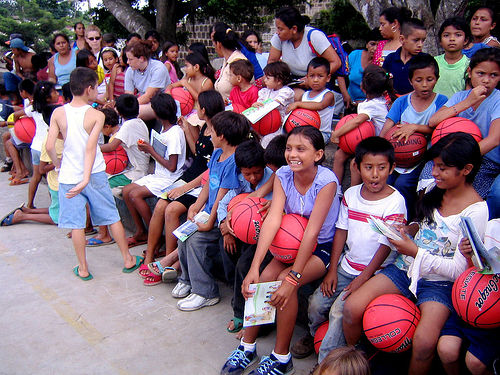

In [38]:
Image.open(img_name_val[5])

References
a group of children sitting down and holding basketballs on their laps .
several kids are sitting down and holding basketballs
a large group of young children with basketballs .
group of little kids waiting for the game to start
young children holding basketballs .
Hypothesis
kids are sitting around a race .
Bleu Score =  0.27313058850276045


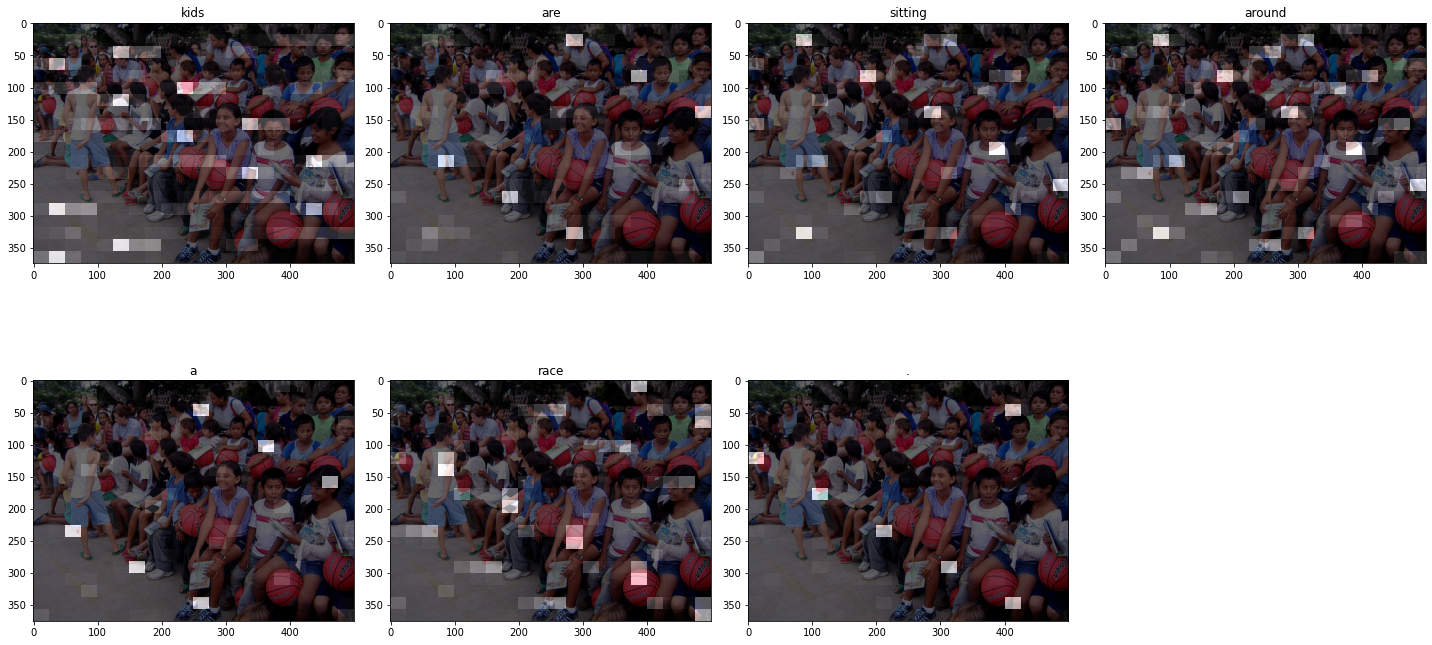

In [39]:
get_bleu([5])

In [40]:
corpus=[i for i in range(0,6000,5)]

In [41]:
get_bleu(corpus)

Bleu Score =  0.08337800676874882


# **Βελτιώσεις (και παραδοτέα)**

#### Παρακάτω ακολουθείται η ίδια μεθοδολογία με το tutorial και με τη διαδικασία που ακολουθήσαμε προηγουμένως με κάποιες σημαντικές βελτιώσεις. Όπως η προεξεργασία του κειμένου, η αλλαγή του encoder με άλλον καλύτερο, η χρήση embeddings, η προσθήκη μηχανισμού ομαλοποίησης, δοκιμές με διαφορετικό decoder ή και αλλαγή του αριθμού των units του GRU και τέλος η χρήση beam search. 

### Προεπεξεργασία κειμένου

In [42]:
# Group all captions together having the same image ID.
len_image_path_to_caption = collections.defaultdict(list)
for row in range(annotations.shape[1]):
    caption =  f"<start> {annotations[row][2]} <end>"
    image_path = "image_dir/" + annotations[row][0]
    len_image_path_to_caption[image_path].append(len(caption.split(' ')))

In [43]:
cap_len = []
for x in len_image_path_to_caption.values():
    for j in x:
        cap_len.append(j)
cap_len = np.unique(cap_len)

In [44]:
print(len(cap_len))
print(cap_len)

73
[ 4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27
 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51
 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 68 69 70 71 72 73 74 75 77
 81]


In [45]:
a = list(len_image_path_to_caption.values())
a = list(np.concatenate((a), axis=0))
lengths = dict((i, a.count(i)) for i in cap_len)
lengths

{4: 12,
 5: 42,
 6: 278,
 7: 1037,
 8: 3350,
 9: 7388,
 10: 10388,
 11: 12353,
 12: 13912,
 13: 14520,
 14: 13608,
 15: 12080,
 16: 10626,
 17: 9303,
 18: 7597,
 19: 6155,
 20: 5050,
 21: 4077,
 22: 3275,
 23: 2591,
 24: 2208,
 25: 1688,
 26: 1299,
 27: 1105,
 28: 938,
 29: 721,
 30: 606,
 31: 464,
 32: 375,
 33: 337,
 34: 255,
 35: 219,
 36: 159,
 37: 154,
 38: 127,
 39: 92,
 40: 94,
 41: 59,
 42: 56,
 43: 49,
 44: 35,
 45: 38,
 46: 24,
 47: 23,
 48: 20,
 49: 10,
 50: 9,
 51: 15,
 52: 7,
 53: 18,
 54: 12,
 55: 8,
 56: 4,
 57: 9,
 58: 6,
 59: 5,
 60: 2,
 61: 4,
 62: 2,
 63: 1,
 64: 1,
 65: 1,
 66: 2,
 68: 1,
 69: 2,
 70: 1,
 71: 2,
 72: 1,
 73: 1,
 74: 1,
 75: 1,
 77: 1,
 81: 1}

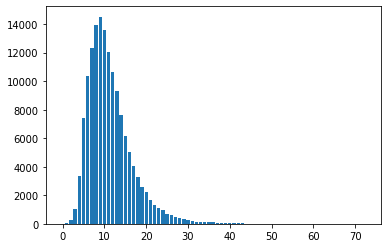

In [46]:
names = list(lengths.keys())
values = list(lengths.values())

plt.bar(range(len(lengths)), values)
plt.show()

#### Κρατήσαμε τα πιο συχνά εμφανιζόμενα και πιο λογικά caption lengths ώστε να μην έχουμε ούτε πολύ μεγάλα ούτε πολύ μικρά captions.

In [47]:
final_len = cap_len[3:32]
print('Κρατάμε', len(final_len), 'μήκη captions')
print(final_len)

Κρατάμε 29 μήκη captions
[ 7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30
 31 32 33 34 35]


In [48]:
new_image_path_to_caption = collections.defaultdict(list)
for row in range(annotations.shape[1]):
    caption =  f"<start> {annotations[row][2]} <end>"
    image_path = "image_dir/" + annotations[row][0]
    if len(caption.split(' ')) in final_len:
        new_image_path_to_caption[image_path].append(caption)

In [49]:
print(new_image_path_to_caption["image_dir/_10106775.jpg"])

['<start> A young girl dressed in a yellow sweater smiles and looks up while in front of a purple and yellow cake with a plastic flower on top of it . <end>', '<start> A little girl wearing a white sweater , seated in front of a colorful cake , she laughs with an upward gaze . <end>', '<start> A young girl laughs and waves her arms while sitting in front of a multicolored birthday cake . <end>', '<start> A young girl is sitting in a chair with a cake on the table . <end>', '<start> A smiling girl sits in front of a cake while looking up . <end>']


In [50]:
print(len(list(new_image_path_to_caption.keys())))

29782


In [51]:
image_paths = list(new_image_path_to_caption.keys())
random.shuffle(image_paths)

train_image_paths = image_paths[:6000]
print(len(train_image_paths))

6000


In [52]:
train_captions = []
img_name_vector = []

for image_path in train_image_paths:
    caption_list = new_image_path_to_caption[image_path]
    train_captions.extend(caption_list)
    img_name_vector.extend([image_path] * len(caption_list))

<start> A festival taking place on a street beside a store entitled " De Credito " . <end>


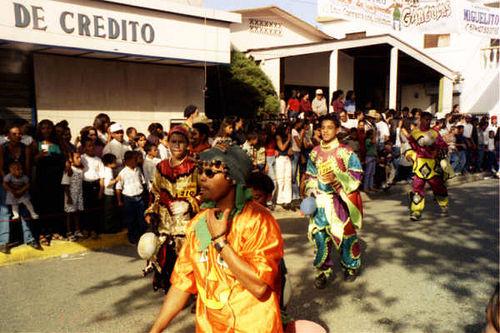

In [53]:
print(train_captions[0])
Image.open(img_name_vector[0])

### Preprocess the images using Xception

#### Χρησιμοποιούμε τον encoder Xception. Η λειτουργία του είναι παρόμοια με αυτή του InceptionV3 και το αναμενόμενο input ίδιο οπότε κάνουμε την ίδια προεπεξεργασία.

In [54]:
def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.keras.layers.Resizing(299, 299)(img)
    img = tf.keras.applications.xception.preprocess_input(img)
    return img, image_path

### Initialize Xception and load the pretrained Imagenet weights

#### Σύμφωνα με την εκφώνηση προσθέσαμε στα dense layers regularization penalties (συγκεκριμενα penalty l2) για το optimization του loss function.

In [55]:
image_model = tf.keras.applications.Xception(include_top=False, weights='imagenet')

image_model.trainable = True

# adding regularization
regularizer = tf.keras.regularizers.l2()

for layer in image_model.layers:
    for attr in ['kernel_regularizer']:
        if hasattr(layer, attr):
            setattr(layer, attr, regularizer)

new_input = image_model.input
hidden_layer = image_model.layers[-1].output

image_features_extract_model = tf.keras.Model(new_input, hidden_layer)

83697664/83683744 [==============================] - 0s 0us/step


In [56]:
from tqdm import tqdm

# Get unique images
encode_train = sorted(set(img_name_vector))

# Feel free to change batch_size according to your system configuration
image_dataset = tf.data.Dataset.from_tensor_slices(encode_train)
image_dataset = image_dataset.map(
  load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(16)

for img, path in tqdm(image_dataset):
    batch_features = image_features_extract_model(img)
    batch_features = tf.reshape(batch_features,
                              (batch_features.shape[0], -1, batch_features.shape[3]))

    for bf, p in zip(batch_features, path):
        path_of_feature = p.numpy().decode("utf-8")
        np.save(path_of_feature, bf.numpy())

100%|██████████| 375/375 [01:21<00:00,  4.58it/s]


### Preprocess and tokenize the captions

In [57]:
caption_dataset = tf.data.Dataset.from_tensor_slices(train_captions)

# We will override the default standardization of TextVectorization to preserve
# "<>" characters, so we preserve the tokens for the <start> and <end>.
def standardize(inputs):
    inputs = tf.strings.lower(inputs)
    return tf.strings.regex_replace(inputs, r"!\"#$%&\(\)\*\+.,-/:;=?@\[\\\]^_`{|}~", "")

# Max word count for a caption.
max_length = 35
# Use the top 5000 words for a vocabulary.
vocabulary_size = 5000
tokenizer = tf.keras.layers.TextVectorization(
    max_tokens=vocabulary_size,
    standardize=standardize,
    output_sequence_length=max_length)
# Learn the vocabulary from the caption data.
tokenizer.adapt(caption_dataset)

In [58]:
# Create the tokenized vectors
cap_vector = caption_dataset.map(lambda x: tokenizer(x))

In [59]:
# Create mappings for words to indices and indicies to words.
word_to_index = tf.keras.layers.StringLookup(
    mask_token="",
    vocabulary=tokenizer.get_vocabulary())
index_to_word = tf.keras.layers.StringLookup(
    mask_token="",
    vocabulary=tokenizer.get_vocabulary(),
    invert=True)

In [60]:
word_index = dict(zip(tokenizer.get_vocabulary(), range(len(tokenizer.get_vocabulary()))))

### Embeddings

#### Χρησιμοποιήσαμε μια υλοποίηση από pretrained embeddings για το keras, όπως φαίνεται παρακάτω.
https://keras.io/examples/nlp/pretrained_word_embeddings/

In [61]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2022-03-09 19:35:11--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2022-03-09 19:35:12--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2022-03-09 19:35:12--  http://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6

In [62]:
!unzip -q glove.6B.zip

In [63]:
embeddings_index = {}
with open("glove.6B.200d.txt") as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))

Found 400000 word vectors.


In [64]:
num_tokens = len(tokenizer.get_vocabulary()) + 2
embedding_dim = 200
hits = 0
misses = 0

# Prepare embedding matrix
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        # This includes the representation for "padding" and "OOV"
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1
print("Converted %d words (%d misses)" % (hits, misses))

Converted 4959 words (41 misses)


### Split the data into training and testing

In [65]:
img_to_cap_vector = collections.defaultdict(list)
for img, cap in zip(img_name_vector, cap_vector):
    img_to_cap_vector[img].append(cap)

# Create training and validation sets using an 80-20 split randomly.
img_keys = list(img_to_cap_vector.keys())
random.shuffle(img_keys)

slice_index = int(len(img_keys)*0.8)
img_name_train_keys, img_name_val_keys = img_keys[:slice_index], img_keys[slice_index:]

img_name_train = []
cap_train = []
for imgt in img_name_train_keys:
    capt_len = len(img_to_cap_vector[imgt])
    img_name_train.extend([imgt] * capt_len)
    cap_train.extend(img_to_cap_vector[imgt])

img_name_val = []
cap_val = []
for imgv in img_name_val_keys:
    capv_len = len(img_to_cap_vector[imgv])
    img_name_val.extend([imgv] * capv_len)
    cap_val.extend(img_to_cap_vector[imgv])

In [66]:
len(img_name_train), len(cap_train), len(img_name_val), len(cap_val)

(23772, 23772, 5952, 5952)

### Create a tf.data dataset for training

In [67]:
# Feel free to change these parameters according to your system's configuration

BATCH_SIZE = 64
BUFFER_SIZE = 1000
# embedding_dim = 256
units = 512
num_steps = len(img_name_train) // BATCH_SIZE
# Shape of the vector extracted from InceptionV3 is (64, 2048)
# These two variables represent that vector shape
features_shape = 2048
attention_features_shape = 100

In [68]:
# Load the numpy files
def map_func(img_name, cap):
    img_tensor = np.load(img_name.decode('utf-8')+'.npy')
    return img_tensor, cap

In [69]:
dataset = tf.data.Dataset.from_tensor_slices((img_name_train, cap_train))

# Use map to load the numpy files in parallel
dataset = dataset.map(lambda item1, item2: tf.numpy_function(
          map_func, [item1, item2], [tf.float32, tf.int64]),
          num_parallel_calls=tf.data.AUTOTUNE)

# Shuffle and batch
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

### Model

In [70]:
class BahdanauAttention(tf.keras.Model):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, features, hidden):
        # features(CNN_encoder output) shape == (batch_size, 64, embedding_dim)

        # hidden shape == (batch_size, hidden_size)
        # hidden_with_time_axis shape == (batch_size, 1, hidden_size)
        hidden_with_time_axis = tf.expand_dims(hidden, 1)

        # attention_hidden_layer shape == (batch_size, 64, units)
        attention_hidden_layer = (tf.nn.tanh(self.W1(features) +
                                             self.W2(hidden_with_time_axis)))

        # score shape == (batch_size, 64, 1)
        # This gives you an unnormalized score for each image feature.
        score = self.V(attention_hidden_layer)

        # attention_weights shape == (batch_size, 64, 1)
        attention_weights = tf.nn.softmax(score, axis=1)

        # context_vector shape after sum == (batch_size, hidden_size)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

In [71]:
class CNN_Encoder(tf.keras.Model):
    # Since you have already extracted the features and dumped it
    # This encoder passes those features through a Fully connected layer
    def __init__(self, embedding_dim):
        super(CNN_Encoder, self).__init__()
        # shape after fc == (batch_size, 64, embedding_dim)
        self.fc = tf.keras.layers.Dense(embedding_dim)

    def call(self, x):
        x = self.fc(x)
        x = tf.nn.relu(x)
        return x

In [72]:
class RNN_Decoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size):
        super(RNN_Decoder, self).__init__()
        self.units = units

#         self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.embedding = tf.keras.layers.Embedding(num_tokens, embedding_dim, embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
        trainable=False,)
        self.gru = tf.keras.layers.GRU(self.units,
                                       return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer='glorot_uniform')
        self.fc1 = tf.keras.layers.Dense(self.units)
        self.fc2 = tf.keras.layers.Dense(vocab_size)

        self.attention = BahdanauAttention(self.units)

    def call(self, x, features, hidden):
        # defining attention as a separate model
        context_vector, attention_weights = self.attention(features, hidden)

        # x shape after passing through embedding == (batch_size, 1, embedding_dim)
        x = self.embedding(x)

        # x shape after concatenation == (batch_size, 1, embedding_dim + hidden_size)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        
        # passing the concatenated vector to the GRU
        output, state = self.gru(x)   #for lstm: output, state, _ = self.lstm(x) 

        # shape == (batch_size, max_length, hidden_size)
        x = self.fc1(output)

        # x shape == (batch_size * max_length, hidden_size)
        x = tf.reshape(x, (-1, x.shape[2]))

        # output shape == (batch_size * max_length, vocab)
        x = self.fc2(x)

        return x, state, attention_weights

    def reset_state(self, batch_size):
        return tf.zeros((batch_size, self.units))

In [73]:
encoder = CNN_Encoder(embedding_dim)
decoder = RNN_Decoder(embedding_dim, units, tokenizer.vocabulary_size())

In [74]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')


def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)

    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    return tf.reduce_mean(loss_)

### Checkpoint

In [75]:
checkpoint_path = "./checkpoints/train2"
ckpt = tf.train.Checkpoint(encoder=encoder, decoder=decoder, optimizer=optimizer)
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

In [76]:
start_epoch = 0
if ckpt_manager.latest_checkpoint:
    start_epoch = int(ckpt_manager.latest_checkpoint.split('-')[-1])
    # restoring the latest checkpoint in checkpoint_path
    ckpt.restore(ckpt_manager.latest_checkpoint)

### Training

In [77]:
# adding this in a separate cell because if you run the training cell
# many times, the loss_plot array will be reset
loss_plot = []

In [78]:
@tf.function
def train_step(img_tensor, target):
    loss = 0

    # initializing the hidden state for each batch
    # because the captions are not related from image to image
    hidden = decoder.reset_state(batch_size=target.shape[0])

    dec_input = tf.expand_dims([word_to_index(tf.convert_to_tensor(''))]* target.shape[0], 1)

    with tf.GradientTape() as tape:
        features = encoder(img_tensor)

        for i in range(1, target.shape[1]):
            # passing the features through the decoder
            predictions, hidden, _ = decoder(dec_input, features, hidden)

            loss += loss_function(target[:, i], predictions)

            # using teacher forcing
            dec_input = tf.expand_dims(target[:, i], 1)

    total_loss = (loss / int(target.shape[1]))

    trainable_variables = encoder.trainable_variables + decoder.trainable_variables

    gradients = tape.gradient(loss, trainable_variables)

    optimizer.apply_gradients(zip(gradients, trainable_variables))

    return loss, total_loss

In [79]:
EPOCHS = 40
start_epoch = 0

for epoch in range(start_epoch, EPOCHS):
    start = time.time()
    total_loss = 0
    for (batch, (img_tensor, target)) in enumerate(dataset):
        batch_loss, t_loss = train_step(img_tensor, target)
        total_loss += t_loss

        if batch % 100 == 0:
            average_batch_loss = batch_loss.numpy()/int(target.shape[1])
            print(f'Epoch {epoch+1} Batch {batch} Loss {average_batch_loss:.4f}')
    # storing the epoch end loss value to plot later
    loss_plot.append(total_loss / num_steps)

    if epoch % 5 == 0:
        ckpt_manager.save()

    print(f'Epoch {epoch+1} Loss {total_loss/num_steps:.6f}')
    print(f'Time taken for 1 epoch {time.time()-start:.2f} sec\n')

Epoch 1 Batch 0 Loss 3.2920
Epoch 1 Batch 100 Loss 1.7409
Epoch 1 Batch 200 Loss 1.5727
Epoch 1 Batch 300 Loss 1.5799
Epoch 1 Loss 1.702008
Time taken for 1 epoch 117.34 sec

Epoch 2 Batch 0 Loss 1.4450
Epoch 2 Batch 100 Loss 1.4744
Epoch 2 Batch 200 Loss 1.3841
Epoch 2 Batch 300 Loss 1.2869
Epoch 2 Loss 1.391323
Time taken for 1 epoch 51.58 sec

Epoch 3 Batch 0 Loss 1.2327
Epoch 3 Batch 100 Loss 1.3636
Epoch 3 Batch 200 Loss 1.3598
Epoch 3 Batch 300 Loss 1.2394
Epoch 3 Loss 1.269361
Time taken for 1 epoch 50.33 sec

Epoch 4 Batch 0 Loss 1.1154
Epoch 4 Batch 100 Loss 1.2245
Epoch 4 Batch 200 Loss 1.1028
Epoch 4 Batch 300 Loss 1.2215
Epoch 4 Loss 1.180814
Time taken for 1 epoch 50.26 sec

Epoch 5 Batch 0 Loss 1.0655
Epoch 5 Batch 100 Loss 1.2122
Epoch 5 Batch 200 Loss 1.1508
Epoch 5 Batch 300 Loss 0.9794
Epoch 5 Loss 1.106057
Time taken for 1 epoch 51.03 sec

Epoch 6 Batch 0 Loss 1.0350
Epoch 6 Batch 100 Loss 0.9715
Epoch 6 Batch 200 Loss 1.0200
Epoch 6 Batch 300 Loss 1.0321
Epoch 6 Los

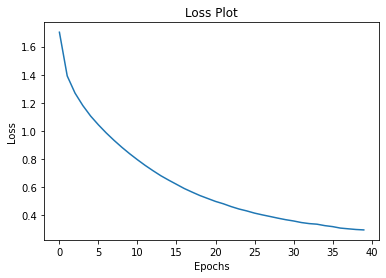

In [80]:
plt.plot(loss_plot)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.show()

### Caption!

#### Για το κομμάτι του beam search προσπαθήσαμε να προσαρμόσουμε αυτόν τον υλοποιημένο κώδικα της beam search στην ήδη υπάρχουσα συνάρτηση evaluate χωρίς επιτυχία 😢, παρακάτω φαίνεται σε σχόλιο η προσπάθεια μας.
https://yashk2810.github.io/Image-Captioning-using-InceptionV3-and-Beam-Search/

In [81]:
# def evaluate(image):
#     attention_plot = np.zeros((max_length, attention_features_shape))

#     hidden = decoder.reset_state(batch_size=1)

#     temp_input = tf.expand_dims(load_image(image)[0], 0)
#     img_tensor_val = image_features_extract_model(temp_input)
#     img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))

#     features = encoder(img_tensor_val)
    
#     start = [word_index["<start>"]]
    
#     start_word = [[start, 0.0]]
    
#     beam_index = 3
    
#     dec_input = tf.expand_dims([word_to_index(tf.convert_to_tensor('<start>'))], 0)
    
#     max_len = 55
    
#     while len(start_word[0][0]) < max_len:
#         temp = []
#         i = 0
#         for s in start_word:
#             #par_caps = sequence.pad_sequences([s[0]], maxlen=max_len, padding='post')
#             #e = encoding_test[image[len(images):]]
#             #preds = final_model.predict([np.array([e]), np.array(par_caps)])
#             preds, hidden, attention_weights = decoder(dec_input, features, hidden)

#             attention_plot[i] = tf.reshape(attention_weights, (-1, )).numpy()
            
#             print("predictions")
#             print(preds)
            
#             word_preds = np.argsort(preds[0])[-beam_index:]
            
#             # Getting the top <beam_index>(n) predictions and creating a 
#             # new list so as to put them via the model again
#             for w in word_preds:
#                 next_cap, prob = s[0][:], s[1]
#                 next_cap.append(w)
#                 prob += preds[0][w]
#                 temp.append([next_cap, prob])
#             i = i + 1
        
#         print("temporary predictions")
#         print(temp)
#         start_word = temp
#         # Sorting according to the probabilities
#         start_word = sorted(start_word, reverse=False, key=lambda l: l[1])
#         # Getting the top words
#         start_word = start_word[-beam_index:]
#         print("new start word")
#         print(start_word)
    
#     start_word = start_word[-1][0]
#     intermediate_caption = [index_to_word(int(i)).numpy().decode('UTF-8') for i in start_word]
    
#     result = []
    
#     for i in intermediate_caption:
#         if i != '<end>':
#             result.append(i)
#         else:
#             break
    
#     result = ' '.join(result[1:])
#     attention_plot = attention_plot[:len(result), : ] 
#     return result, attention_plot

In [82]:
def evaluate(image):
    attention_plot = np.zeros((max_length, attention_features_shape))

    hidden = decoder.reset_state(batch_size=1)

    temp_input = tf.expand_dims(load_image(image)[0], 0)
    img_tensor_val = image_features_extract_model(temp_input)
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))

    features = encoder(img_tensor_val)

    dec_input = tf.expand_dims([word_to_index(tf.convert_to_tensor('<start>'))], 0)
    result = []

    for i in range(max_length):
        predictions, hidden, attention_weights = decoder(dec_input, features, hidden)

        attention_plot[i] = tf.reshape(attention_weights, (-1, )).numpy()

        predicted_id = tf.random.categorical(predictions, 1)[0][0].numpy()
        
        #predicted_word = tf.compat.as_text(index_to_word(predicted_id).numpy())
        predicted_word = index_to_word(int(predicted_id)).numpy().decode('UTF-8')
        result.append(predicted_word)

        if predicted_word == '<end>':
            return result, attention_plot

        dec_input = tf.expand_dims([predicted_id], 0)

    attention_plot = attention_plot[:len(result), :]
    return result, attention_plot

In [83]:
def plot_attention(image, result, attention_plot):
    temp_image = np.array(Image.open(image))
    
    fig = plt.figure(figsize=(20, 20))
    
    len_result = len(result)
    for i in range(len_result):
        temp_att = np.resize(attention_plot[i], (20, 20))
        grid_size = max(int(np.ceil(len_result/2)), 2)
        ax = fig.add_subplot(grid_size, grid_size, i+1)
        ax.set_title(result[i])
        img = ax.imshow(temp_image)
        ax.imshow(temp_att, cmap='gray', alpha=0.6, extent=img.get_extent())
    
    plt.tight_layout()
    plt.show()

Real Caption: <start> person in a boat with a paddle in hand <end>
Prediction Caption: a man is [UNK] kayaks going turned upside down a body of water . <end>


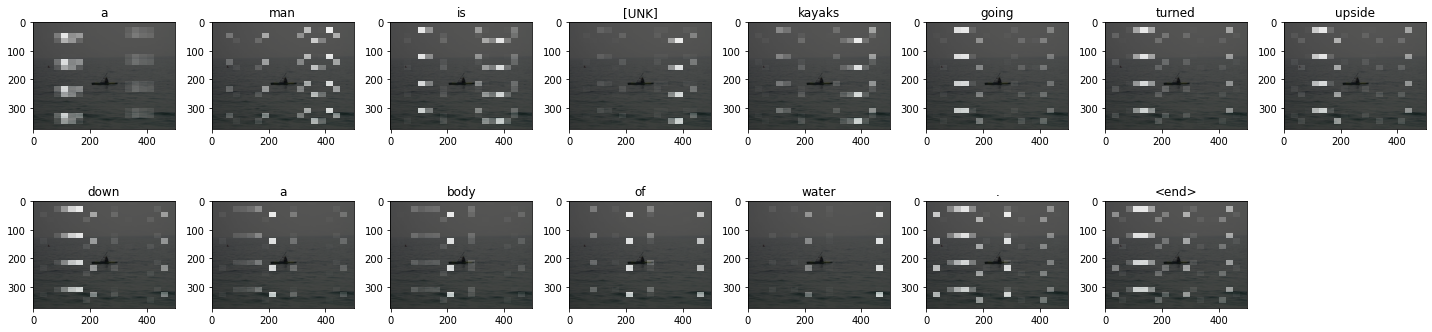

In [84]:
# captions on the validation set
rid = np.random.randint(0, len(img_name_val))
image = img_name_val[rid]
real_caption = ' '.join([tf.compat.as_text(index_to_word(i).numpy())
                         for i in cap_val[rid] if i not in [0]])
result, attention_plot = evaluate(image)

print('Real Caption:', real_caption)
print('Prediction Caption:', ' '.join(result))
plot_attention(image, result, attention_plot)

### Evaluate Models

In [85]:
def get_bleu(first, last):
    references = []
    hypothesis = []
    verbal = first == last
    if verbal: print('References')
    rid = first
    while rid <= last and rid < len(img_name_val):
        image_ref = []
        old_rid = rid
        while rid < len(img_name_val) and img_name_val[rid] == img_name_val[old_rid]:
            reference = [tf.compat.as_text(index_to_word(i).numpy()) for i in cap_val[rid] if i not in [0]][1:-1]
            if verbal: print(' '.join(reference))
            image_ref.append(reference)
            old_rid = rid
            rid+=1
        references.append(image_ref)
        image = img_name_val[old_rid]
        res, attention_plot = evaluate(image)
        res = res[:-1]
        hypothesis.append(res)
    bleu_score = nltk.translate.bleu_score.corpus_bleu(references, hypothesis, weights=(0.4, 0.3, 0.2, 0.1), smoothing_function=SmoothingFunction().method1)
    if verbal:
        print('Hypothesis')
        print(' '.join(res))
    print('Bleu Score = ', bleu_score)
    if verbal: plot_attention(image, res, attention_plot)

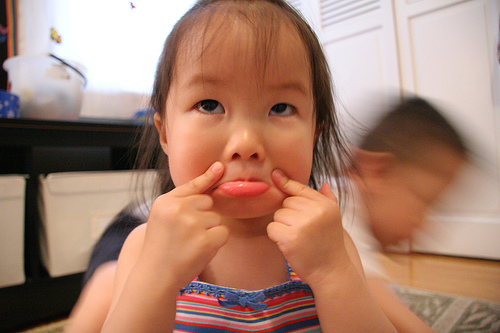

In [86]:
Image.open(img_name_val[1])

References
this little girl is making a face to show that she is unhappy .
a young asian girl makes a silly face for the camera .
a young girls makes a silly face for the camera .
a little girl in the [UNK] making faces .
Hypothesis
a girl in a multicolored smile .
Bleu Score =  0.12134426988894406


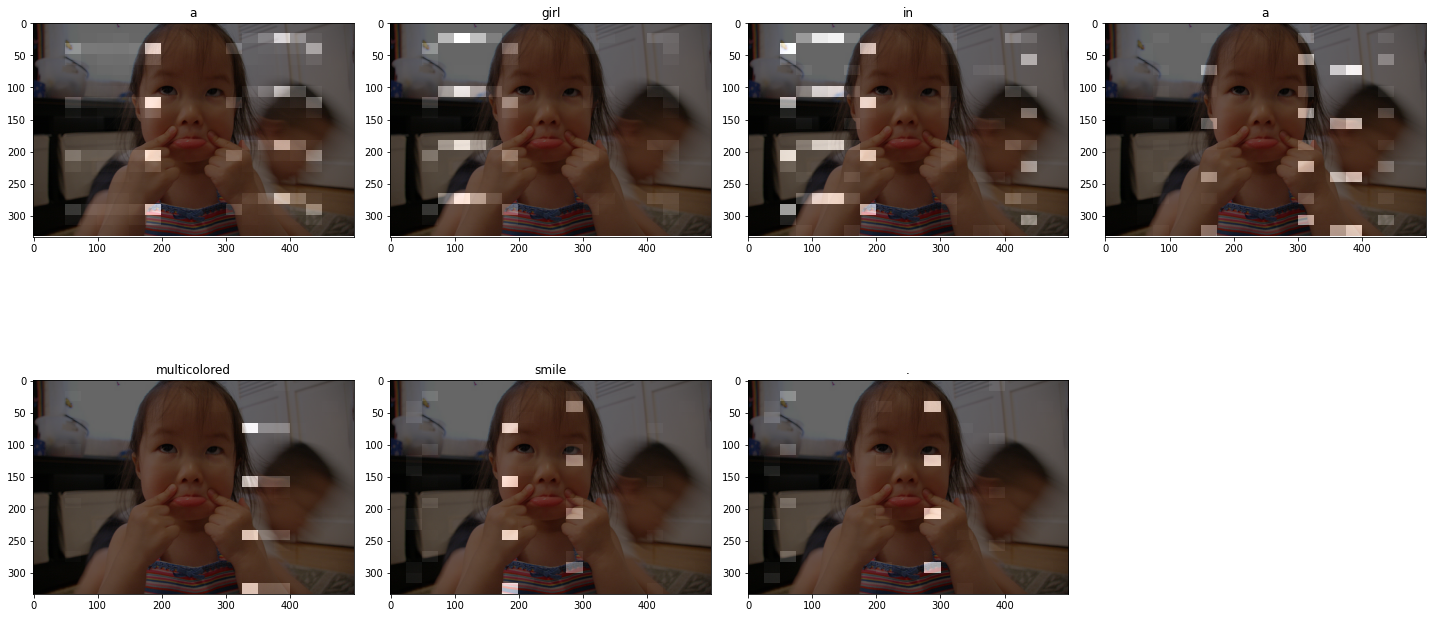

In [87]:
get_bleu(1,1)

In [88]:
get_bleu(0,len(img_name_val)-1)

Bleu Score =  0.10818273461438951


### Κάποια αποτελέσματα

#### Παρακάτω βλέπουμε μαζεμένα τα αποτελέσματα για διάφορες επιλογές και αλλαγές σε παραμέτρους για τον decoder. Όπως φαίνεται τα αποτελέσματα δεν διέφεραν και πολύ αλλά για μείωση των units στο GRU φαίνεται να πετυχαίνουμε μικρότερο bleu score. Ενώ για LSTM φαίνεται επίσης να παίρνουμε λίγο χειρότερα αποτελέσματα. Οι τιμές αυτές όπως αναγράφεται είναι για 20 εποχές καθώς δεν ήταν δυνατόν να τρέξουμε τόσες φορές για περισσότερες εποχές. Φαίνεται να μην καταφέραμε να ξεπεράσουμε για πολύ το σκόρ που πετύχαμε στο out of the box μοντέλο αλλά το βελτιώσαμε κάπως. Παρόλο που δεν βελτιώσαμε τα αποτελέσματα ποσοτικά, από την μεριά του bleu score, φαίνεται τα αποτελέσματα ποιοτικά να είναι αρκετά καλύτερα. Τα captions δηλαδή που παράγουμε να είναι νοηματικά καλύτερα από του out of the box μοντέλου. Αν είχαμε στη διάθεση μας περισσότερους πόρους, τρέχοντας το training για περισσότερες εποχές θα καταφέρναμε να μειώσουμε και άλλο το loss και να πετύχουμε ακόμη καλύτερα αποτελέσματα. 

In [89]:
from tabulate import tabulate
print('For 20 epochs')
print(tabulate([['GRU', 128, 0.086356], ['GRU', 256, 0.097036], ['GRU', 512, 0.112031], ['LSTM', 512, 0.101537], ['OOB - GRU', 512, 0.087925]], headers=['Decoder', 'Unit size', 'Bleu Score']))
print('\n*OOB = Out of the box')

For 20 epochs
Decoder      Unit size    Bleu Score
---------  -----------  ------------
GRU                128      0.086356
GRU                256      0.097036
GRU                512      0.112031
LSTM               512      0.101537
OOB - GRU          512      0.087925

*OOB = Out of the box
